# Projet : Filtrage de Kalman
_Auteur : ClapTrap – Objectif : Réaliser un filtre qui retrouve biais et angle d'un IMU en déplacement 1D(rot) pour lequel on dispose des mesures d'accélération et de gyroscopie_
_Date : 2026-04-03_
---


## 1. Liens avec le web

Regrouper ici tous les liens.

https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/04b2bea802321086effbd99402fc13c893d11110/10-Unscented-Kalman-Filter.ipynb

https://www.ferdinandpiette.com/blog/2011/04/exemple-dutilisation-du-filtre-de-kalman/



## 2. Installation et import des bibliothèques

Regrouper ici toutes les installations `pip` propres à Colab et tous les imports.

In [12]:
# import math
import numpy as np
import matplotlib.pyplot as plt

from Test_Kalman_5 import Test_Kalman_5_fns as tk

## 3. Définition des paramètres globaux

Centraliser ici les constantes, chemins, et paramètres configurables.

In [13]:
# Paramètres globaux

tk.TotalTime = 100
tk.SampleSize = 1000  # nombre d'instants de mesure  # <<<
tk.TimeStep = float(tk.TotalTime / tk.SampleSize)  # période d'échantillonage (s)  # <<<

RandomSeed = 123
np.random.seed(RandomSeed)

# Paramètres du modèle de mouvement  # <<<

tk.TrueInitialAlpha = 45.0  # angle initial vrai (°)        # <<<
tk.TrueInitialAlphadot = 0.0  # vitesse angulaire initiale vraie (°/s)        # <<<
tk.TrueInitialBias = 20.0  # biais de vitesse angulaire vrai (°/s)             # <<<

tk.SupposedInitialAlpha = 0.0  # angle initial supposé (°)        # <<<
tk.SupposedInitialAlphadot = 0.0  # vitesse angulaire initiale supposé (°/s)        # <<<
tk.SupposedInitialBias = 0.0  # biais de vitesse angulaire supposé (°/s)             # <<<

tk.MeasurementAccelNoiseStd = 0.1  # => R écart-type du bruit de mesure sur alpha  # <<<
tk.MeasurementAlphadotNoiseStd = 5.0  # => R écart-type du bruit de mesure sur alphadot   # <<<

tk.ProcessAlphaNoiseStd = 0.1  # => Q bruit de processus (sur alpha)  # <<<
tk.ProcessAlphadotNoiseStd = 10  # => Q bruit de processus (sur alphadot)  # <<<
tk.ProcessBiasNoiseStd = 0.10  # => Q bruit de processus (sur bias)  # <<<

tk.ProcessInitialConfidenceStd = 1000  # => Q bruit de processus (sur alpha)  # <<<


## 4. Définition des fonctions principales

Regrouper ici les fonctions réutilisables pour le traitement.

## 5. Exécution principale

Utiliser les fonctions définies pour produire les résultats.

In [14]:
# Génération du comportement vrai et des mesures bruitées
(TimeArray,
 TrueAlphaArray,
 TrueAlphadotArray,
 MeasuredAccelArray,
 MeasuredAlphadotArray) = tk.GenerateTrueValuesAndMeasurements()

TimeStep : 0.1


In [15]:
# Création et configuration du filtre de Kalman
UKF = tk.CreateUnscentedKalmanFilter()

In [16]:
# Génération du comportement vrai et des mesures bruitées
# Application du filtre sur toutes les mesures
(EstimatedAlphaArray,
 EstimatedAlphadotArray,
 EstimatedBiasArray) = tk.ApplyUnscentedKalmanFilterOnMeasurements(
    UKF,
    MeasuredAccelArray,
    MeasuredAlphadotArray
)

print("FirstTrueAlpha     =", TrueAlphaArray[0])
print("FirstMeasuredAccel =", MeasuredAccelArray[0])
print("FirstEstimatedAlpha =", EstimatedAlphaArray[0])
print("FirstTrueAlphadot     =", TrueAlphadotArray[0])
print("FirstEstimatedAlphadot =", EstimatedAlphadotArray[0])

FirstTrueAlpha     = 45.0
FirstMeasuredAccel = -7.045280583770088
FirstEstimatedAlpha = 279.3940839676257
FirstTrueAlphadot     = 0.0
FirstEstimatedAlphadot = 319.45707377685943


## 6. Visualisation des résultats

Tracer les données ou les résultats principaux.

In [17]:
print(f"MeasurementAccelNoiseStd = {tk.MeasurementAccelNoiseStd}")
print(f"MeasurementAlphadotNoiseStd = {tk.MeasurementAlphadotNoiseStd}")
print(f"ProcessAlphaNoiseStd = {tk.ProcessAlphaNoiseStd}")
print(f"ProcessAlphadotNoiseStd = {tk.ProcessAlphadotNoiseStd}")
print(f"ProcessBiasNoiseStd = {tk.ProcessBiasNoiseStd}")

MeasurementAccelNoiseStd = 0.1
MeasurementAlphadotNoiseStd = 5.0
ProcessAlphaNoiseStd = 0.1
ProcessAlphadotNoiseStd = 10
ProcessBiasNoiseStd = 0.1


In [18]:
doRoll = True
# doRoll = False
if doRoll:
    TrueAlphaArray = tk.Modulo(-180., 360.0, TrueAlphaArray)
    EstimatedAlphaArray = tk.Modulo(-180., 360.0, EstimatedAlphaArray)
    EstimatedAlphadotArray = tk.Roll(-20., 20.0, EstimatedAlphadotArray)
    EstimatedBiasArray = tk.Roll(-20., 120.0, EstimatedBiasArray)
    #
    # TrueAlphaArray = tk.Roll(-180., 360.0, TrueAlphaArray)
    # EstimatedAlphaArray = tk.AngleModulo360(EstimatedAlphaArray, -180., 180.0)
    # EstimatedAlphadotArray = tk.AngleModulo360(EstimatedAlphadotArray, -20., 20.0)
    # EstimatedBiasArray = tk.AngleModulo360(EstimatedBiasArray, -20., 120.0)

In [19]:
alphaMin = -200
alphaMax = 200
alphadotMin = -50
alphadotMax = 50
biasMin = -100
biasMax = 100
doClip = True
# doClip = False

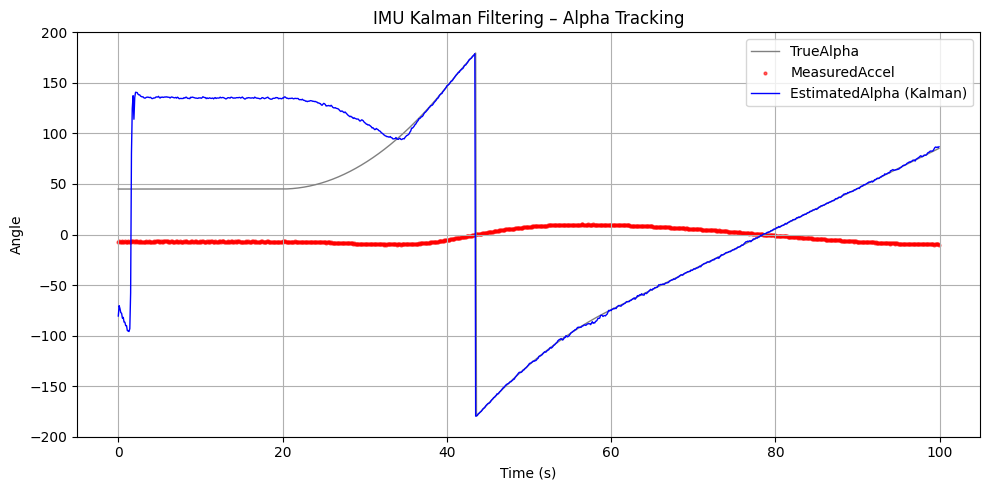

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(TimeArray,
         TrueAlphaArray,
         label="TrueAlpha",
         color="grey",
         linewidth=1)

plt.scatter(TimeArray,
            MeasuredAccelArray,
            label="MeasuredAccel",
            color="red",
            s=4,
            alpha=0.6)

plt.plot(TimeArray,
         EstimatedAlphaArray,
         label="EstimatedAlpha (Kalman)",
         color="blue",
         linewidth=1)

plt.title("IMU Kalman Filtering – Alpha Tracking")
plt.xlabel("Time (s)")
plt.ylabel("Angle")

if doClip:
    plt.ylim(alphaMin, alphaMax)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

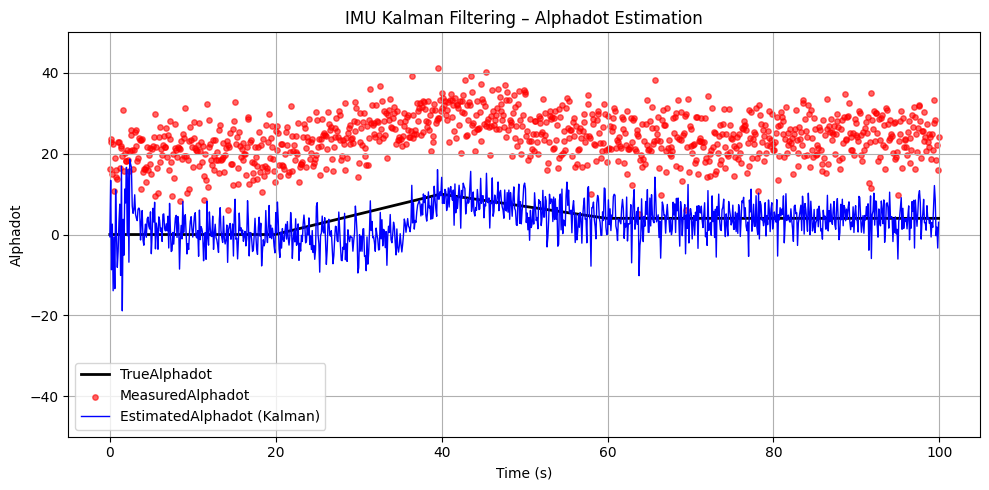

In [21]:
plt.figure(figsize=(10, 5))  # <<<

plt.plot(TimeArray,
         TrueAlphadotArray,
         label="TrueAlphadot",
         color="black",
         linewidth=2)  # <<<

plt.scatter(TimeArray,
            MeasuredAlphadotArray,
            label="MeasuredAlphadot",
            color="red",
            s=15,
            alpha=0.6)

plt.plot(TimeArray,
         EstimatedAlphadotArray,
         label="EstimatedAlphadot (Kalman)",
         color="blue",
         linewidth=1)  # <<<

plt.title("IMU Kalman Filtering – Alphadot Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Alphadot")  # <<<

if doClip:
    plt.ylim(alphadotMin, alphadotMax)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

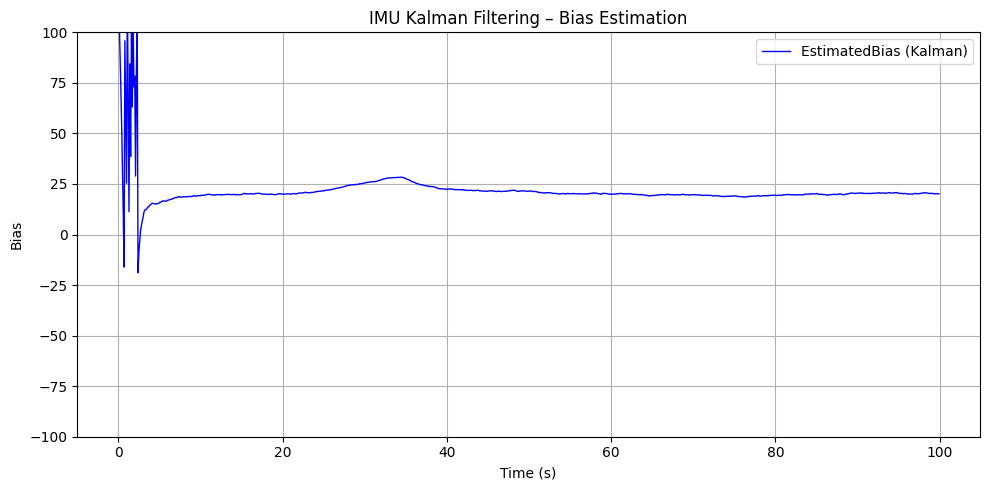

In [22]:
plt.figure(figsize=(10, 5))  # <<<

plt.plot(TimeArray,
         EstimatedBiasArray,
         label="EstimatedBias (Kalman)",
         color="blue",
         linewidth=1)  # <<<

plt.title("IMU Kalman Filtering – Bias Estimation")  # <<<
plt.xlabel("Time (s)")
plt.ylabel("Bias")  # <<<

if doClip:
    plt.ylim(biasMin, biasMax)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()